In [1]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 54.8 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.



================ RAW DATA ================
<RawEDF | S004R02 (1).edf, 64 x 9760 (61.0 s), ~4.8 MiB, data loaded>
Number of channels: 64
Sampling frequency: 160.0 Hz
Duration: 60.99375 seconds

Channel names:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']

Plotting RAW EEG - ALL CHANNELS
Using matplotlib as 2D backend.


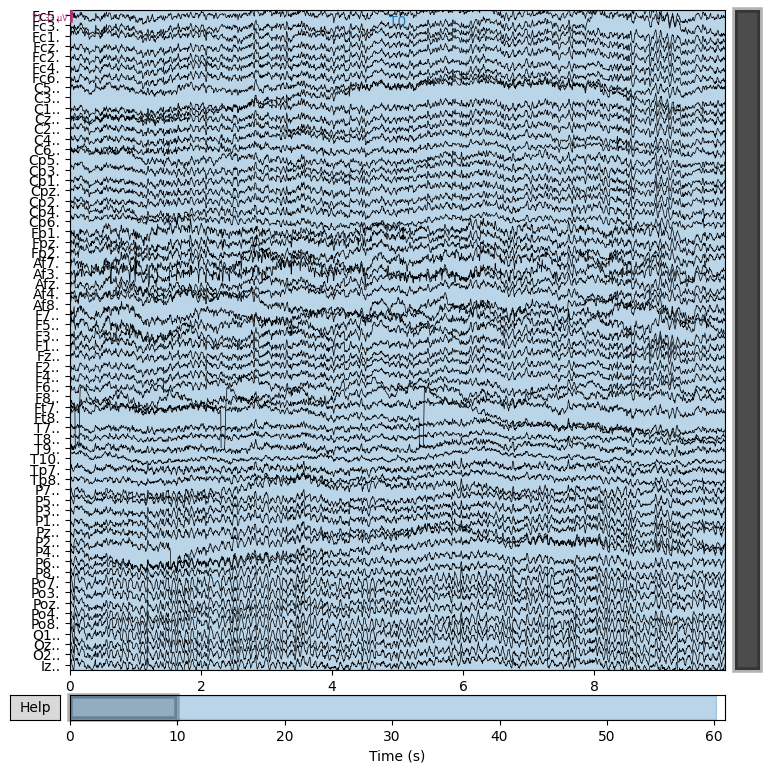


================ EEG CHANNELS ONLY ================
Number of EEG channels: 64
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


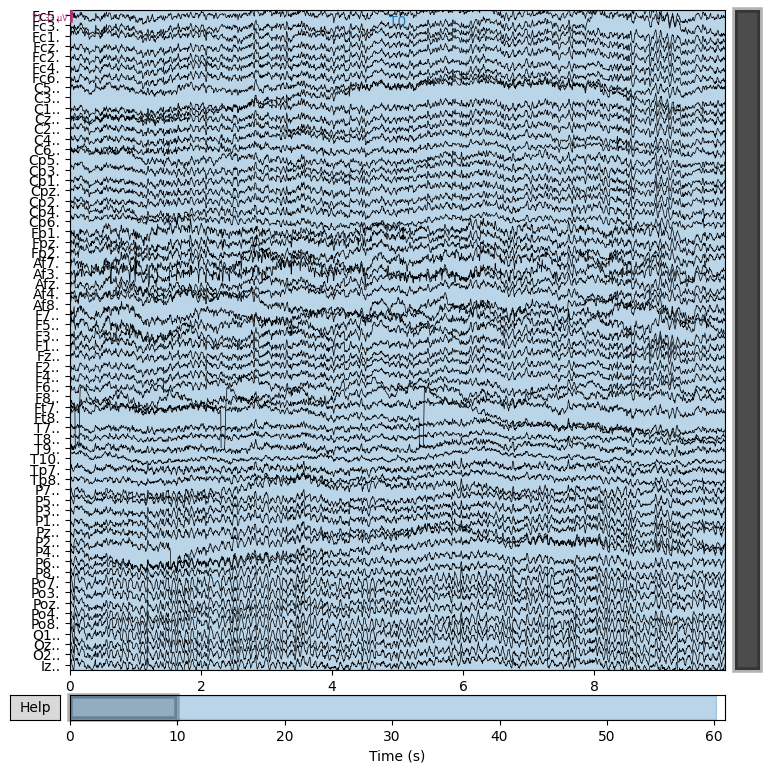


================ AVERAGE REFERENCE ================
Average reference applied.


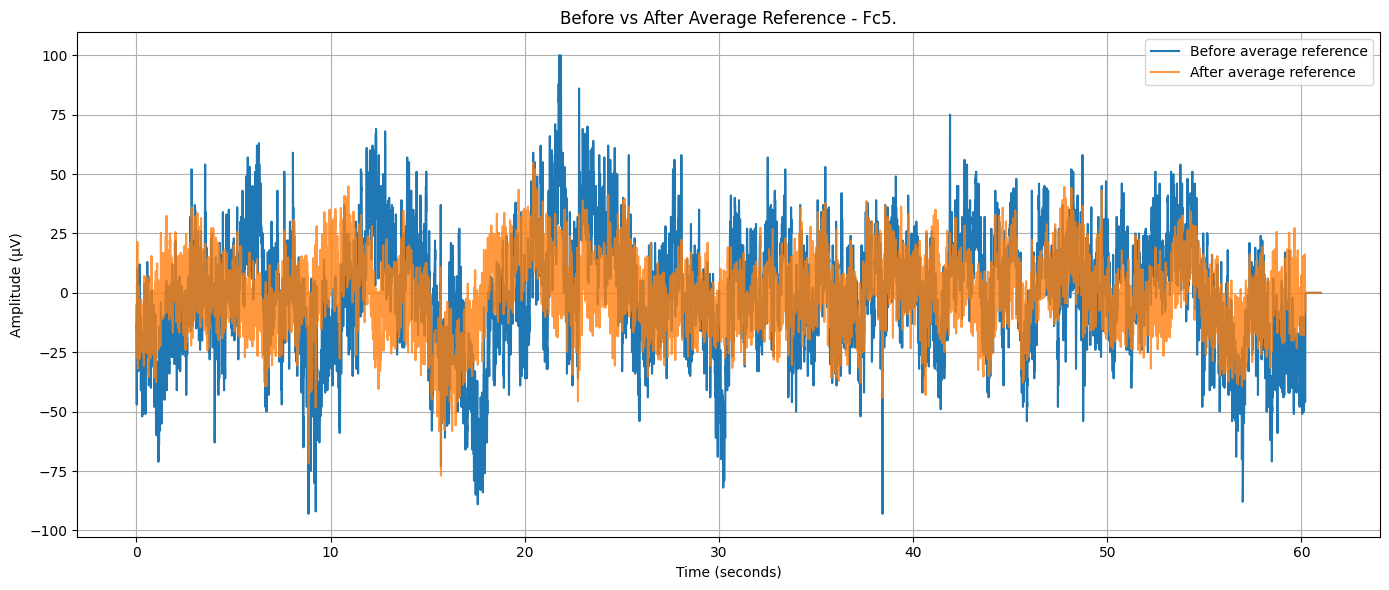


================ NOTCH FILTER ================
Notch filter frequency: 50 Hz


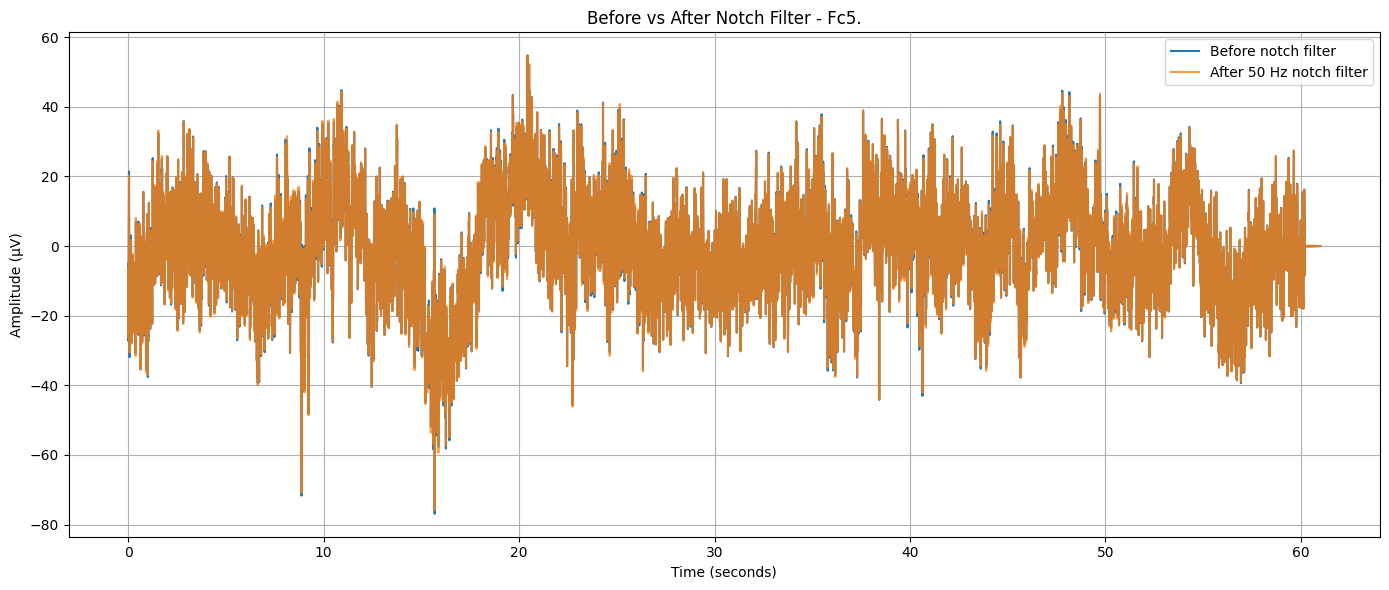


================ BAND-PASS FILTER ================
Band-pass filter: 1-40 Hz


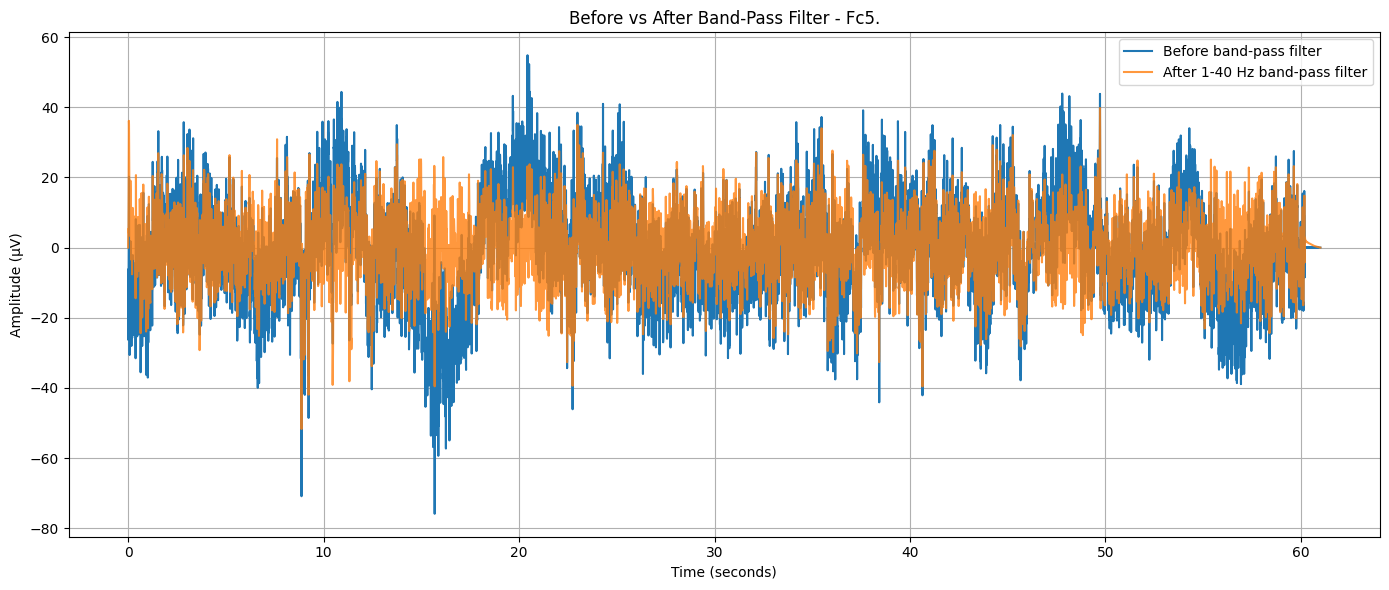


================ ARTIFACT DETECTION ================
Artifact threshold: ±150 µV
Artifact samples: 75
Artifact percentage: 0.77%


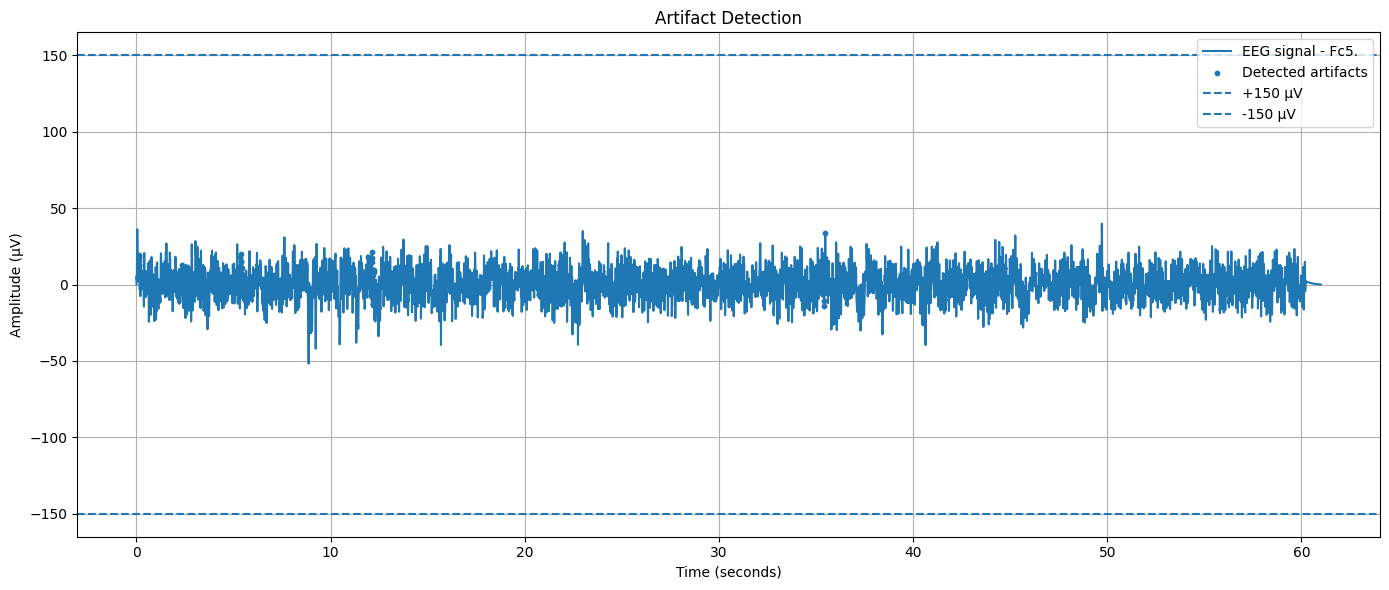


================ EPOCHING ================
Epoch duration: 2.0 seconds
Number of epochs: 30
Epoch shape: (30, 64, 320)

================ ARTIFACT REJECTION ================
Epochs before rejection: 30
Epochs after rejection: 21
Removed artifact epochs: 9


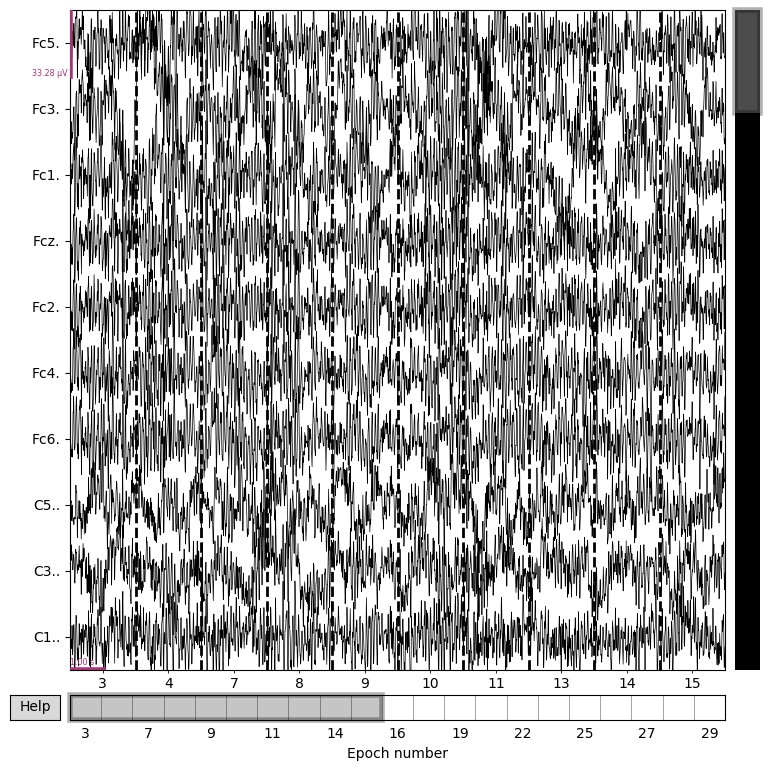


================ BEFORE NORMALIZATION ================
Shape: (21, 64, 321)
Mean: 8.041849669822759e-24
Standard deviation: 1.392297414391321e-05

================ AFTER NORMALIZATION ================
Shape: (21, 64, 321)
Mean: 5.303246015862638e-18
Standard deviation: 0.9999999999999998


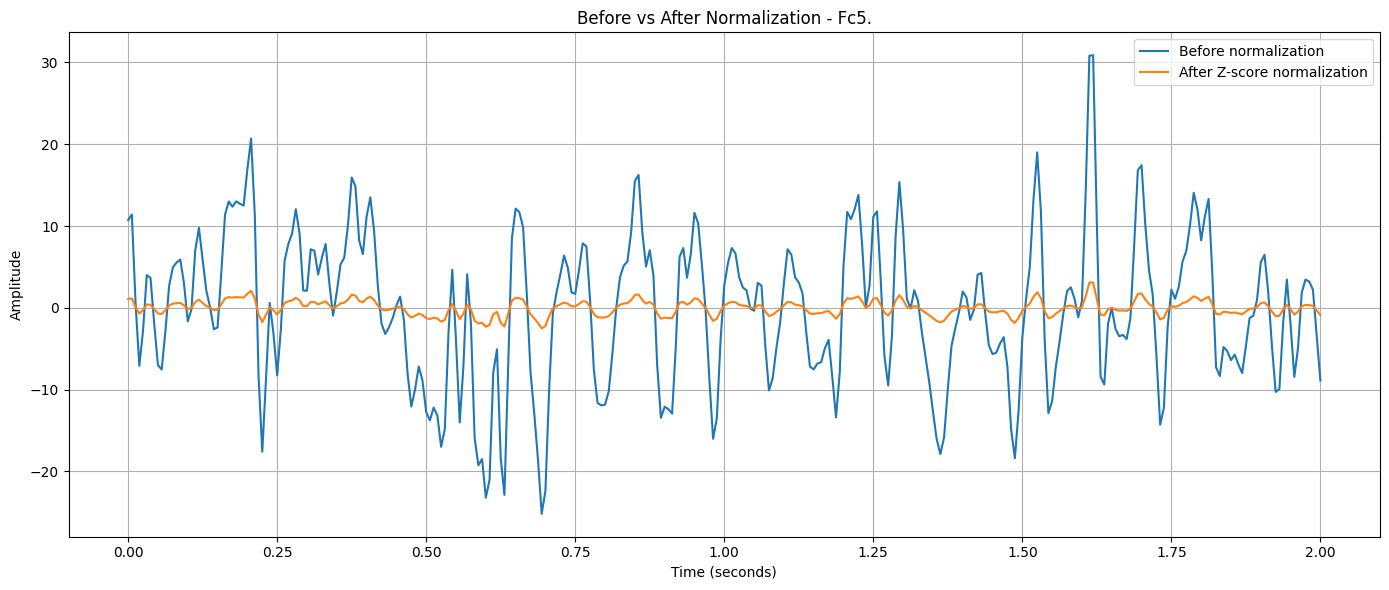


================ FINAL DATASET ================
Final data shape: (21, 64, 321)
Number of epochs: 21
Number of channels: 64
Samples per epoch: 321
Sampling frequency: 160.0 Hz


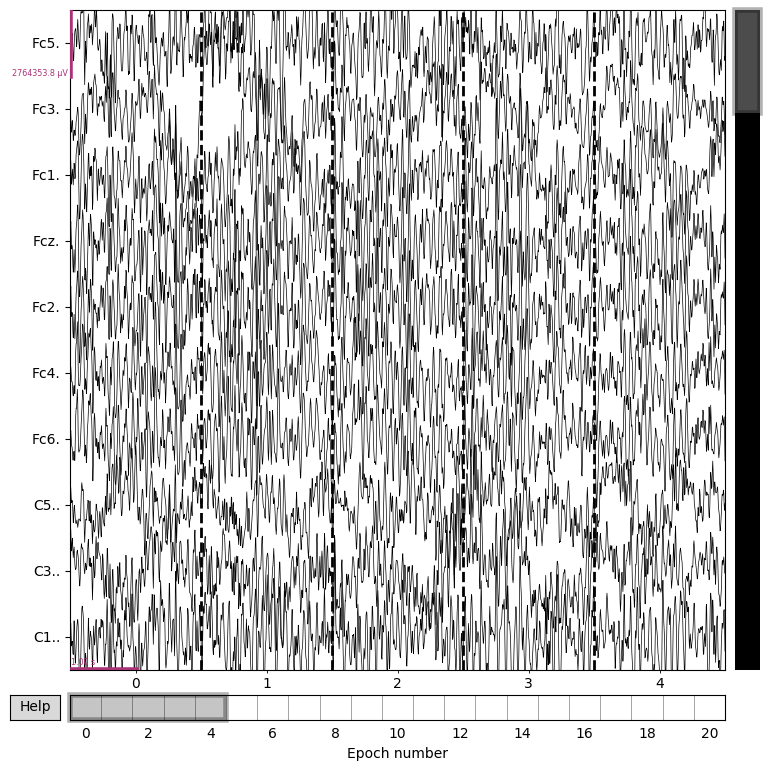


Final preprocessed EEG saved as:
S004R02_preprocessed-epo.fif
NumPy dataset saved as: S004R02_preprocessed.npy

================ PREPROCESSING COMPLETE ================


In [2]:
# ============================================================
# EEG PREPROCESSING PIPELINE
# Dataset: S004R02.edf
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import mne

from scipy.stats import zscore


# ============================================================
# 1. LOAD EEG DATA
# ============================================================

file_path = r"/content/S004R02 (1).edf"

raw = mne.io.read_raw_edf(
    file_path,
    preload=True,
    verbose=False
)

print("\n================ RAW DATA ================")
print(raw)
print("Number of channels:", len(raw.ch_names))
print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Duration:", raw.times[-1], "seconds")

print("\nChannel names:")
print(raw.ch_names)


# ============================================================
# 2. PLOT RAW SIGNAL - ALL CHANNELS
# ============================================================

raw_all = raw.copy()

print("\nPlotting RAW EEG - ALL CHANNELS")

raw_all.plot(
    n_channels=64,
    duration=10,
    scalings="auto",
    title="Before preprocessing - All 64 channels"
)

plt.show()


# ============================================================
# 3. SELECT EEG CHANNELS ONLY
# ============================================================

# Automatically detect EEG channels
eeg_picks = mne.pick_types(
    raw.info,
    eeg=True,
    exclude="bads"
)

raw_eeg = raw.copy().pick(eeg_picks)

print("\n================ EEG CHANNELS ONLY ================")
print("Number of EEG channels:", len(raw_eeg.ch_names))
print(raw_eeg.ch_names)


# Plot EEG channels only
raw_eeg.plot(
    n_channels=min(64, len(raw_eeg.ch_names)),
    duration=10,
    scalings="auto",
    title="After selecting EEG channels only"
)

plt.show()


# ============================================================
# 4. SAVE DATA BEFORE REFERENCE
# ============================================================

raw_before_reference = raw_eeg.copy()


# ============================================================
# 5. AVERAGE REFERENCE
# ============================================================

raw_after_reference = raw_eeg.copy()

raw_after_reference.set_eeg_reference(
    ref_channels="average",
    projection=False,
    verbose=False
)

print("\n================ AVERAGE REFERENCE ================")
print("Average reference applied.")


# ============================================================
# 6. BEFORE vs AFTER AVERAGE REFERENCE
# ============================================================

channel_to_plot = raw_after_reference.ch_names[0]

data_before_ref = raw_before_reference.get_data(
    picks=[channel_to_plot]
)[0]

data_after_ref = raw_after_reference.get_data(
    picks=[channel_to_plot]
)[0]

time = raw_after_reference.times

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    data_before_ref * 1e6,
    label="Before average reference"
)

plt.plot(
    time,
    data_after_ref * 1e6,
    label="After average reference",
    alpha=0.8
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title(
    f"Before vs After Average Reference - {channel_to_plot}"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 7. NOTCH FILTER
# ============================================================

# Indian power-line frequency = 50 Hz
notch_freq = 50

raw_before_notch = raw_after_reference.copy()

raw_after_notch = raw_after_reference.copy()

raw_after_notch.notch_filter(
    freqs=[notch_freq],
    verbose=False
)

print("\n================ NOTCH FILTER ================")
print("Notch filter frequency:", notch_freq, "Hz")


# ============================================================
# 8. BEFORE vs AFTER NOTCH FILTER
# ============================================================

data_before_notch = raw_before_notch.get_data(
    picks=[channel_to_plot]
)[0]

data_after_notch = raw_after_notch.get_data(
    picks=[channel_to_plot]
)[0]

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    data_before_notch * 1e6,
    label="Before notch filter"
)

plt.plot(
    time,
    data_after_notch * 1e6,
    label="After 50 Hz notch filter",
    alpha=0.8
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title(
    f"Before vs After Notch Filter - {channel_to_plot}"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 9. BAND-PASS FILTER
# ============================================================

# Typical EEG band-pass:
# Low cutoff  = 1 Hz
# High cutoff = 40 Hz

low_cutoff = 1
high_cutoff = 40

raw_before_bandpass = raw_after_notch.copy()

raw_after_bandpass = raw_after_notch.copy()

raw_after_bandpass.filter(
    l_freq=low_cutoff,
    h_freq=high_cutoff,
    fir_design="firwin",
    verbose=False
)

print("\n================ BAND-PASS FILTER ================")
print(
    f"Band-pass filter: {low_cutoff}-{high_cutoff} Hz"
)


# ============================================================
# 10. BEFORE vs AFTER BAND-PASS FILTER
# ============================================================

data_before_bandpass = raw_before_bandpass.get_data(
    picks=[channel_to_plot]
)[0]

data_after_bandpass = raw_after_bandpass.get_data(
    picks=[channel_to_plot]
)[0]

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    data_before_bandpass * 1e6,
    label="Before band-pass filter"
)

plt.plot(
    time,
    data_after_bandpass * 1e6,
    label="After 1-40 Hz band-pass filter",
    alpha=0.8
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title(
    f"Before vs After Band-Pass Filter - {channel_to_plot}"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 11. ARTIFACT DETECTION
# ============================================================

# Artifact detection using amplitude threshold.
#
# Here we mark samples/epochs containing amplitudes
# greater than +/- 150 µV as potentially contaminated.

artifact_threshold = 150e-6   # 150 µV

data_filtered = raw_after_bandpass.get_data()

artifact_mask = np.any(
    np.abs(data_filtered) > artifact_threshold,
    axis=0
)

artifact_percentage = (
    np.sum(artifact_mask) /
    len(artifact_mask)
) * 100

print("\n================ ARTIFACT DETECTION ================")

print(
    f"Artifact threshold: ±{artifact_threshold * 1e6:.0f} µV"
)

print(
    f"Artifact samples: {np.sum(artifact_mask)}"
)

print(
    f"Artifact percentage: {artifact_percentage:.2f}%"
)


# ============================================================
# 12. VISUALIZE ARTIFACT DETECTION
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    data_filtered[0] * 1e6,
    label=f"EEG signal - {channel_to_plot}"
)

artifact_times = time[artifact_mask]

if len(artifact_times) > 0:

    artifact_signal = data_filtered[0][artifact_mask] * 1e6

    plt.scatter(
        artifact_times,
        artifact_signal,
        label="Detected artifacts",
        s=10
    )

plt.axhline(
    artifact_threshold * 1e6,
    linestyle="--",
    label="+150 µV"
)

plt.axhline(
    -artifact_threshold * 1e6,
    linestyle="--",
    label="-150 µV"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title("Artifact Detection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 13. EPOCHING
# ============================================================

# Since this EDF contains a T0 annotation and may not contain
# usable motor-imagery event labels for automatic task-specific
# epoching, we create fixed-length epochs.

epoch_duration = 2.0       # seconds
epoch_overlap = 0.0        # seconds

epochs = mne.make_fixed_length_epochs(
    raw_after_bandpass,
    duration=epoch_duration,
    overlap=epoch_overlap,
    preload=True,
    reject_by_annotation=False,
    verbose=False
)

print("\n================ EPOCHING ================")

print("Epoch duration:", epoch_duration, "seconds")
print("Number of epochs:", len(epochs))
print("Epoch shape:", epochs.get_data().shape)


# ============================================================
# 14. ARTIFACT REJECTION AT EPOCH LEVEL
# ============================================================

# Reject epochs where any EEG channel exceeds ±150 µV.

epochs_clean = mne.Epochs(
    raw_after_bandpass,
    events=epochs.events,
    event_id=None,
    tmin=0,
    tmax=epoch_duration,
    baseline=None,
    preload=True,
    reject={
        "eeg": artifact_threshold
    },
    reject_by_annotation=False,
    verbose=False
)

print("\n================ ARTIFACT REJECTION ================")

print("Epochs before rejection:", len(epochs))
print("Epochs after rejection:", len(epochs_clean))

removed_epochs = len(epochs) - len(epochs_clean)

print("Removed artifact epochs:", removed_epochs)


# ============================================================
# 15. PLOT EPOCHS
# ============================================================

epochs_clean.plot(
    n_epochs=min(10, len(epochs_clean)),
    n_channels=10,
    scalings="auto",
    title="Clean EEG Epochs"
)

plt.show()


# ============================================================
# 16. BEFORE NORMALIZATION
# ============================================================

epochs_before_normalization = epochs_clean.copy()

data_before_normalization = (
    epochs_before_normalization.get_data()
)

print("\n================ BEFORE NORMALIZATION ================")

print(
    "Shape:",
    data_before_normalization.shape
)

print(
    "Mean:",
    np.mean(data_before_normalization)
)

print(
    "Standard deviation:",
    np.std(data_before_normalization)
)


# ============================================================
# 17. NORMALIZATION
# ============================================================

# Z-score normalization
#
# Each channel is normalized across all samples:
#
# normalized = (x - mean) / standard deviation

data = epochs_clean.get_data()

mean = np.mean(
    data,
    axis=(0, 2),
    keepdims=True
)

std = np.std(
    data,
    axis=(0, 2),
    keepdims=True
)

std[std == 0] = 1

data_normalized = (
    data - mean
) / std


# ============================================================
# 18. CREATE NORMALIZED EPOCH OBJECT
# ============================================================

epochs_normalized = mne.EpochsArray(
    data_normalized,
    epochs_clean.info.copy(),
    tmin=epochs_clean.tmin,
    verbose=False
)

print("\n================ AFTER NORMALIZATION ================")

print(
    "Shape:",
    epochs_normalized.get_data().shape
)

print(
    "Mean:",
    np.mean(epochs_normalized.get_data())
)

print(
    "Standard deviation:",
    np.std(epochs_normalized.get_data())
)


# ============================================================
# 19. BEFORE vs AFTER NORMALIZATION
# ============================================================

epoch_number = 0
channel_number = 0

before_norm = data_before_normalization[
    epoch_number,
    channel_number,
    :
]

after_norm = data_normalized[
    epoch_number,
    channel_number,
    :
]

epoch_time = epochs_clean.times

plt.figure(figsize=(14, 6))

plt.plot(
    epoch_time,
    before_norm * 1e6,
    label="Before normalization"
)

plt.plot(
    epoch_time,
    after_norm,
    label="After Z-score normalization"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(
    f"Before vs After Normalization - "
    f"{epochs_clean.ch_names[channel_number]}"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 20. FINAL EEG EPOCHS
# ============================================================

print("\n================ FINAL DATASET ================")

final_data = epochs_normalized.get_data()

print("Final data shape:", final_data.shape)

print(
    "Number of epochs:",
    final_data.shape[0]
)

print(
    "Number of channels:",
    final_data.shape[1]
)

print(
    "Samples per epoch:",
    final_data.shape[2]
)

print(
    "Sampling frequency:",
    epochs_normalized.info["sfreq"],
    "Hz"
)


# ============================================================
# 21. FINAL SIGNAL PLOT
# ============================================================

epochs_normalized.plot(
    n_epochs=min(5, len(epochs_normalized)),
    n_channels=10,
    scalings="auto",
    title="Final Normalized EEG Epochs"
)

plt.show()


# ============================================================
# 22. SAVE FINAL DATA
# ============================================================

output_file = "S004R02_preprocessed-epo.fif"

epochs_normalized.save(
    output_file,
    overwrite=True
)

print("\nFinal preprocessed EEG saved as:")
print(output_file)


# ============================================================
# 23. SAVE NUMPY DATASET
# ============================================================

np.save(
    "S004R02_preprocessed.npy",
    final_data
)

print(
    "NumPy dataset saved as: "
    "S004R02_preprocessed.npy"
)

print("\n================ PREPROCESSING COMPLETE ================")